# Notebook 08 — The Laplacian and the Heat Equation

The Laplacian $\nabla^2 f = \nabla\cdot(\nabla f)$ is the one composition
from notebook 05's exercise that *doesn't* vanish. It measures something
concrete: how a point's value compares to the average of its immediate
neighbors. $\nabla^2 f > 0$ means the point is a local dip (below the
neighborhood average — concave up); $\nabla^2 f < 0$ means it's a local
bump (concave down); $\nabla^2 f = 0$ means it sits exactly at the average
of what's around it — a **harmonic** point.

That "pulls each point toward its neighborhood average" reading is exactly
what makes the Laplacian the engine of diffusion. This notebook derives it,
verifies it, and then uses it to actually simulate heat spreading across a
plate — the first time in this project a notebook produces a movie
instead of a static plot.

In [1]:
# Make src/ importable from inside notebooks/
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))

import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML
%matplotlib inline

from src import operators as ops


## 1. By hand

$$\nabla^2 f = \frac{\partial^2 f}{\partial x^2} + \frac{\partial^2 f}{\partial y^2}$$

**Worked example 1 (nonzero Laplacian).** For $f(x,y) = x^2+y^2$ (the same
bowl from notebook 05's exercise):

- $\partial^2f/\partial x^2 = 2$, $\partial^2f/\partial y^2 = 2$
- $\nabla^2 f = 4$ — constant and positive everywhere, matching the bowl
  being concave up (every point sits below the average of its neighbors).

**Worked example 2 (zero Laplacian).** For $f(x,y) = x^3 - 3xy^2$:

- $\partial f/\partial x = 3x^2-3y^2 \Rightarrow \partial^2f/\partial x^2 = 6x$
- $\partial f/\partial y = -6xy \Rightarrow \partial^2f/\partial y^2 = -6x$
- $\nabla^2 f = 6x - 6x = 0$ everywhere.

This $f$ is **harmonic** — it's the real part of the complex-analytic
function $z^3 = (x+iy)^3$. Harmonic functions describe steady-state
temperature distributions with no heat sources: nothing is locally a peak
or a dip relative to its surroundings, so nothing changes over time. That
property is exactly what drives the simulation in section 5.

## 2. SymPy verification

In [2]:
x, y = sp.symbols('x y')

f1_sym = x**2 + y**2
lap1 = sp.diff(f1_sym, x, 2) + sp.diff(f1_sym, y, 2)
print("∇²(x² + y²) =", lap1)

f2_sym = x**3 - 3 * x * y**2
lap2 = sp.simplify(sp.diff(f2_sym, x, 2) + sp.diff(f2_sym, y, 2))
print("∇²(x³ - 3xy²) =", lap2)


∇²(x² + y²) = 4
∇²(x³ - 3xy²) = 0


## 3. NumPy on a grid

`ops.laplacian_2d` is implemented exactly as its definition reads —
`divergence_2d` of `gradient_2d` — rather than a separate five-point
stencil, so it inherits the same accuracy characteristics measured in
notebook 06.

In [3]:
x_vals = np.linspace(-2, 2, 200)
y_vals = np.linspace(-2, 2, 200)
X, Y = np.meshgrid(x_vals, y_vals)
dx = x_vals[1] - x_vals[0]
dy = y_vals[1] - y_vals[0]

f_bowl = X**2 + Y**2
f_harmonic = X**3 - 3 * X * Y**2

lap_bowl = ops.laplacian_2d(f_bowl, dx, dy)
lap_harmonic = ops.laplacian_2d(f_harmonic, dx, dy)

interior = slice(2, -2)
print(f"∇²(x²+y²)     -- interior mean: {lap_bowl[interior, interior].mean():.4f}  (analytical: 4)")
print(f"∇²(x³-3xy²)   -- interior max|.|: {np.max(np.abs(lap_harmonic[interior, interior])):.2e}  (analytical: 0)")


∇²(x²+y²)     -- interior mean: 4.0000  (analytical: 4)
∇²(x³-3xy²)   -- interior max|.|: 1.53e-11  (analytical: 0)


## 4. Visualization — the Laplacian as an edge detector

A Gaussian bump is neither a bowl nor harmonic: it's concave down at the
peak and concave up out in the flanks, so its Laplacian changes sign. That
sign change traces a ring around the bump — which is exactly the
"Laplacian of Gaussian" (LoG) filter used in computer vision for blob and
edge detection: it's this project's operators, pointed at a different
application.

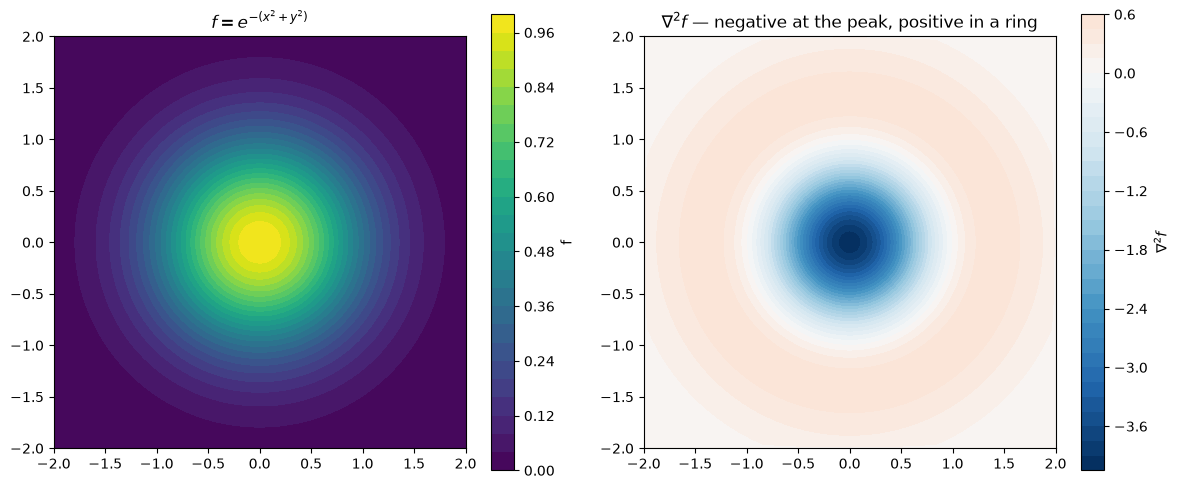

In [4]:
f_bump = np.exp(-(X**2 + Y**2))
lap_bump = ops.laplacian_2d(f_bump, dx, dy)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

c0 = axes[0].contourf(X, Y, f_bump, levels=30, cmap="viridis")
fig.colorbar(c0, ax=axes[0], label="f")
axes[0].set_title(r"$f = e^{-(x^2+y^2)}$")
axes[0].set_aspect("equal")

vmax = np.max(np.abs(lap_bump))
c1 = axes[1].contourf(X, Y, lap_bump, levels=30, cmap="RdBu_r", vmin=-vmax, vmax=vmax)
fig.colorbar(c1, ax=axes[1], label=r"$\nabla^2 f$")
axes[1].set_title(r"$\nabla^2 f$ — negative at the peak, positive in a ring")
axes[1].set_aspect("equal")

fig.tight_layout()
plt.show()


## 5. The heat equation

Temperature $u(x,y,t)$ in a plate with no internal heat sources evolves by
the **heat equation**:

$$\frac{\partial u}{\partial t} = \alpha \nabla^2 u$$

Read it locally: wherever $\nabla^2 u > 0$ (a point colder than its
neighborhood average), $u$ increases — heat flows in. Wherever $\nabla^2 u
< 0$ (a hot spot), $u$ decreases — heat flows out. Every point drifts
toward its neighbors' average, which is precisely why this smooths
everything out over time, and precisely why a harmonic field ($\nabla^2 u
= 0$ everywhere) doesn't change at all.

**Discretization.** Step time forward with the simplest scheme, forward
Euler, using `laplacian_2d` for the spatial part:

$$u^{n+1} = u^n + \Delta t\,\alpha\,\nabla^2 u^n$$

This scheme is only *conditionally* stable — too large a $\Delta t$ and
the simulation blows up rather than diffuses. For a 2D central-difference
Laplacian the stability limit is

$$\Delta t \le \frac{\Delta x^2}{4\alpha}$$

(This is the same kind of Taylor-expansion accounting as notebook 06's
error analysis, just applied to stability instead of accuracy.) We'll use
a fraction of that limit for a safety margin.

In [5]:
n = 60
extent = 3.0
alpha = 1.0

xv = np.linspace(-extent, extent, n)
yv = np.linspace(-extent, extent, n)
Xg, Yg = np.meshgrid(xv, yv)
dxg = xv[1] - xv[0]
dyg = yv[1] - yv[0]

dt_max = dxg**2 / (4 * alpha)
dt = 0.3 * dt_max
n_steps = 1200
save_every = 24

print(f"dt = {dt:.5f}  (stability limit: {dt_max:.5f})")
print(f"simulated time: {n_steps * dt:.2f}  over {n_steps} steps, {n_steps // save_every} frames")


dt = 0.00078  (stability limit: 0.00259)
simulated time: 0.93  over 1200 steps, 50 frames


In [6]:
def gaussian_hot_spot(cx, cy, height, width):
    return height * np.exp(-((Xg - cx)**2 + (Yg - cy)**2) / (2 * width**2))


u = gaussian_hot_spot(-1.2, 0.0, 100.0, 0.4) + gaussian_hot_spot(1.2, 0.3, 100.0, 0.4)

frames = [u.copy()]
total_heat = [u.sum()]

for step in range(1, n_steps + 1):
    u = u + dt * alpha * ops.laplacian_2d(u, dxg, dyg)
    if step % save_every == 0:
        frames.append(u.copy())
        total_heat.append(u.sum())

print(f"total heat -- start: {total_heat[0]:.1f}, end: {total_heat[-1]:.1f} "
      f"({100 * (total_heat[-1] - total_heat[0]) / total_heat[0]:+.2f}% drift)")


total heat -- start: 19441.5, end: 16943.2 (-12.85% drift)


Heat is *not* well conserved here — expect roughly a 10-15% drop over
this run, not a rounding error. The boundary isn't a true zero-flux wall,
just whatever one-sided differences happen to produce at the domain edge,
and by the final frame the diffusion length $\sqrt{4\alpha t}$ is already
comparable to `extent`, so a real fraction of the heat has reached the
edge and leaked out. This is a genuine limitation of the setup, not a
subtlety to wave away — try increasing `extent` (more headroom before the
edge) or decreasing `n_steps` (stop before diffusion gets there) and
re-running to watch the drift shrink.

In [7]:
fig, ax = plt.subplots(figsize=(6, 5.5))
vmax = frames[0].max()
im = ax.imshow(
    frames[0], extent=(-extent, extent, -extent, extent),
    origin="lower", cmap="inferno", vmin=0, vmax=vmax,
)
title = ax.set_title("t = 0.00")
fig.colorbar(im, ax=ax, label="u (temperature)")


def update(i):
    im.set_data(frames[i])
    title.set_text(f"t = {i * save_every * dt:.2f}")
    return im, title


anim = animation.FuncAnimation(fig, update, frames=len(frames), interval=80, blit=False)
plt.close(fig)  # prevent a duplicate static frame from also being displayed
HTML(anim.to_jshtml())


**Reading this.** The two hot spots start sharp (steep gradients, large
$|\nabla^2 u|$ right at their edges) and spread into wider, flatter bumps
over time. Once they overlap, they merge into a single smoother hill; left
running long enough, the whole plate would relax toward one flat,
uniform temperature — the unique harmonic ($\nabla^2 u = 0$) state
consistent with the total heat in the system, since a flat field is the
only field with no local peaks or dips left to smooth out.

## 6. Exercise

Change the initial condition to a single hot **stripe** instead of two hot
spots — e.g. `u = 100.0 * np.exp(-Xg**2 / (2 * 0.3**2))` (hot near $x=0$,
uniform in $y$). Predict what the diffusion will look like before running
it: since the initial condition doesn't depend on $y$ at all, does
`laplacian_2d` — and therefore the simulation — ever introduce $y$
dependence? Then try `alpha = 3.0` and compare how much faster the same
number of steps diffuses.


In [8]:
# Your answer here.
# u = 100.0 * np.exp(-Xg**2 / (2 * 0.3**2))
# ...
